# Marketing bancario: prever quem assina o deposito a prazo

Case tecnico de cientista de dados. A base vem de campanhas de telemarketing de um banco portugues, e a pergunta e direta: da pra prever, antes de ligar, quais clientes tem mais chance de assinar um deposito a prazo?

A variavel alvo e a `y` (assinou ou nao). O foco aqui foi construir um modelo que faca sentido na operacao real, e nao so um numero bonito de acuracia. Por isso boa parte do trabalho gira em torno de uma armadilha classica desta base, a variavel `duration`, que explico na secao de producao.

Sobre rodar o notebook: ele funciona tanto no Databricks (lendo da tabela) quanto localmente no VSCode (lendo o csv da pasta). A celula de carga se vira sozinha nos dois casos.

In [1]:
# instala o que falta. no Databricks isso reinicia o python sozinho.
# se ja estiver tudo instalado, pode pular essa celula.
%pip install xgboost lightgbm mlflow scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.2 MB/s eta 0:00:32
    --------------------------------------- 1.3/101.7 MB 3.6 MB/s eta 0:00:28
    --------------------------------------- 2.4/101.7 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 3.1/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 3.9/101.7 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.7/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 5.8/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 6.6/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.6/101.7 MB 4.1 MB/s eta 0:00:24
   --- ------------------------------------ 8.4/101.7 MB 4.1 MB/s eta 0:00:23
   --- ------------------------------------ 9.4/101.7 MB 4.2 MB/s eta 0


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# mlflow eh opcional. se ele nao estiver instalado (rodando local sem ele), o notebook
# continua funcionando, so nao registra os experimentos.
try:
    import mlflow
    import mlflow.sklearn, mlflow.xgboost, mlflow.lightgbm
    TEM_MLFLOW = True
except ImportError:
    TEM_MLFLOW = False

sns.set_style('whitegrid')
print('bibliotecas carregadas. mlflow disponivel:', TEM_MLFLOW)

bibliotecas carregadas. mlflow disponivel: True


## 1. Carga dos dados

A mesma celula resolve os dois cenarios. No Databricks eu leio da tabela `bank_full` (que veio importada como uma coluna so, entao preciso reparsear pelo separador `;`). Fora do Databricks, leio direto o `bank-full.csv` da pasta do projeto.

In [6]:
from io import StringIO

colunas = ['age','job','marital','education','default','balance','housing','loan',
           'contact','day','month','duration','campaign','pdays','previous','poutcome','y']

try:
    # cenario Databricks
    df_raw = spark.sql("SELECT * FROM workspace.default.bank_full").toPandas()
    bruto = df_raw.iloc[:, 0].str.cat(sep='\n')
    df = pd.read_csv(StringIO(bruto), sep=';', header=None, names=colunas)
    origem = 'Databricks (tabela bank_full)'
except NameError:
    # cenario local no VSCode, aqui nao existe spark
    df = pd.read_csv('C:\\Users\\Jefferson\\Documents\\TesteArmando\\dados\\bank-full.csv', sep=';')
    origem = 'local (bank-full.csv)'

# tira espacos e aspas que as vezes sobram dependendo de como o csv foi salvo
df.columns = df.columns.str.strip()
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip().str.replace('"', '')

print('origem dos dados:', origem)
print(f'{df.shape[0]:,} linhas e {df.shape[1]} colunas')
df.head()

origem dos dados: local (bank-full.csv)
45,211 linhas e 17 colunas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Analise exploratoria

Antes de modelar, quis entender tres coisas: como o alvo esta distribuido, se tem dado faltando, e quais variaveis parecem conversar com a `y`.

In [7]:
print('tipos de cada coluna:')
print(df.dtypes, '\n')

print('nulos de verdade (NaN) na base:', df.isnull().sum().sum())

print('\ndistribuicao do alvo y:')
print(df['y'].value_counts())
taxa = (df['y'] == 'yes').mean() * 100
print(f'\nso {taxa:.1f}% dos clientes assinaram. base bem desbalanceada,')
print('e isso vai pesar na hora de escolher as metricas.')

print('\nestatisticas das numericas:')
display(df.describe().round(2))

tipos de cada coluna:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object 

nulos de verdade (NaN) na base: 0

distribuicao do alvo y:
y
no     39922
yes     5289
Name: count, dtype: int64

so 11.7% dos clientes assinaram. base bem desbalanceada,
e isso vai pesar na hora de escolher as metricas.

estatisticas das numericas:


,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [8]:
# nao tem NaN nessa base, mas tem varios 'unknown' que na pratica sao dado faltando.
# vale ver quanto cada coluna tem disso antes de decidir o que fazer com eles.
for c in df.select_dtypes(include='object').columns:
    pct = (df[c] == 'unknown').mean() * 100
    if pct > 0:
        print(f'{c:12} {pct:5.1f}% unknown')

job            0.6% unknown
education      4.1% unknown
contact       28.8% unknown
poutcome      81.7% unknown


### O que fazer com o dado faltando

Tecnicamente a base nao tem nulo nenhum, mas `poutcome` aparece com mais de 80% de `unknown` e `contact` com quase 30%. Esse `unknown` e o "nao sei" disfarcado de categoria.

Resolvi manter o `unknown` como uma categoria normal, em vez de imputar ou descartar, por dois motivos. Primeiro, modelo de arvore lida bem com isso. Segundo, e mais importante, o proprio "nao sei" costuma ser informativo: `poutcome` igual a `unknown` quase sempre quer dizer que o cliente nunca participou de campanha antes, e isso ja diz algo sobre a chance de ele assinar agora. Jogar essa informacao fora seria desperdicio acredito.

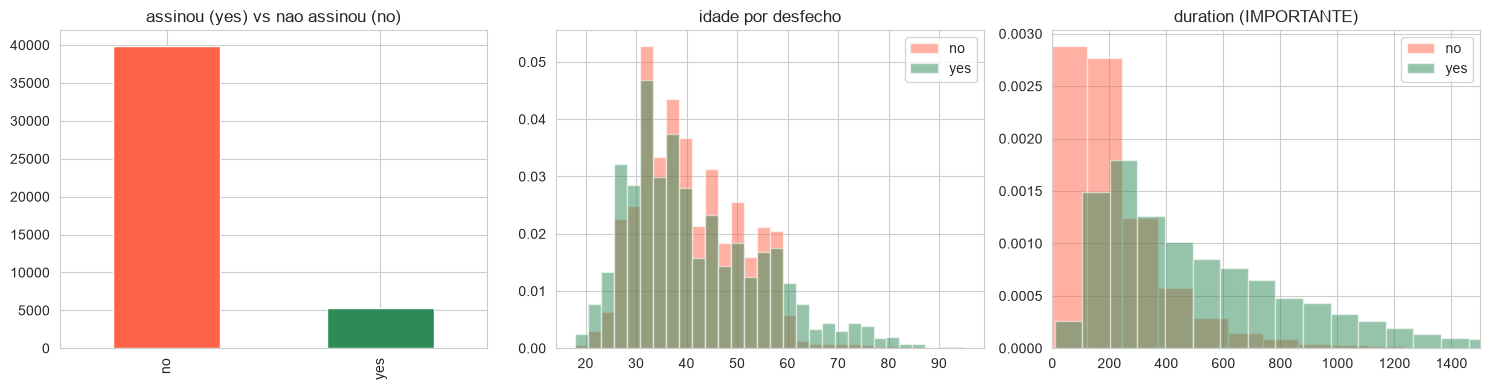

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['tomato', 'seagreen'])
axes[0].set_title('assinou (yes) vs nao assinou (no)')
axes[0].set_xlabel('')

for v, cor in [('no', 'tomato'), ('yes', 'seagreen')]:
    axes[1].hist(df[df['y'] == v]['age'], bins=30, alpha=0.5, label=v, color=cor, density=True)
axes[1].set_title('idade por desfecho')
axes[1].legend()

# ja deixo a pista do problema que aparece la na frente
for v, cor in [('no', 'tomato'), ('yes', 'seagreen')]:
    axes[2].hist(df[df['y'] == v]['duration'], bins=40, alpha=0.5, label=v, color=cor, density=True)
axes[2].set_xlim(0, 1500)
axes[2].set_title('duration (IMPORTANTE)')
axes[2].legend()

plt.tight_layout()
plt.show()

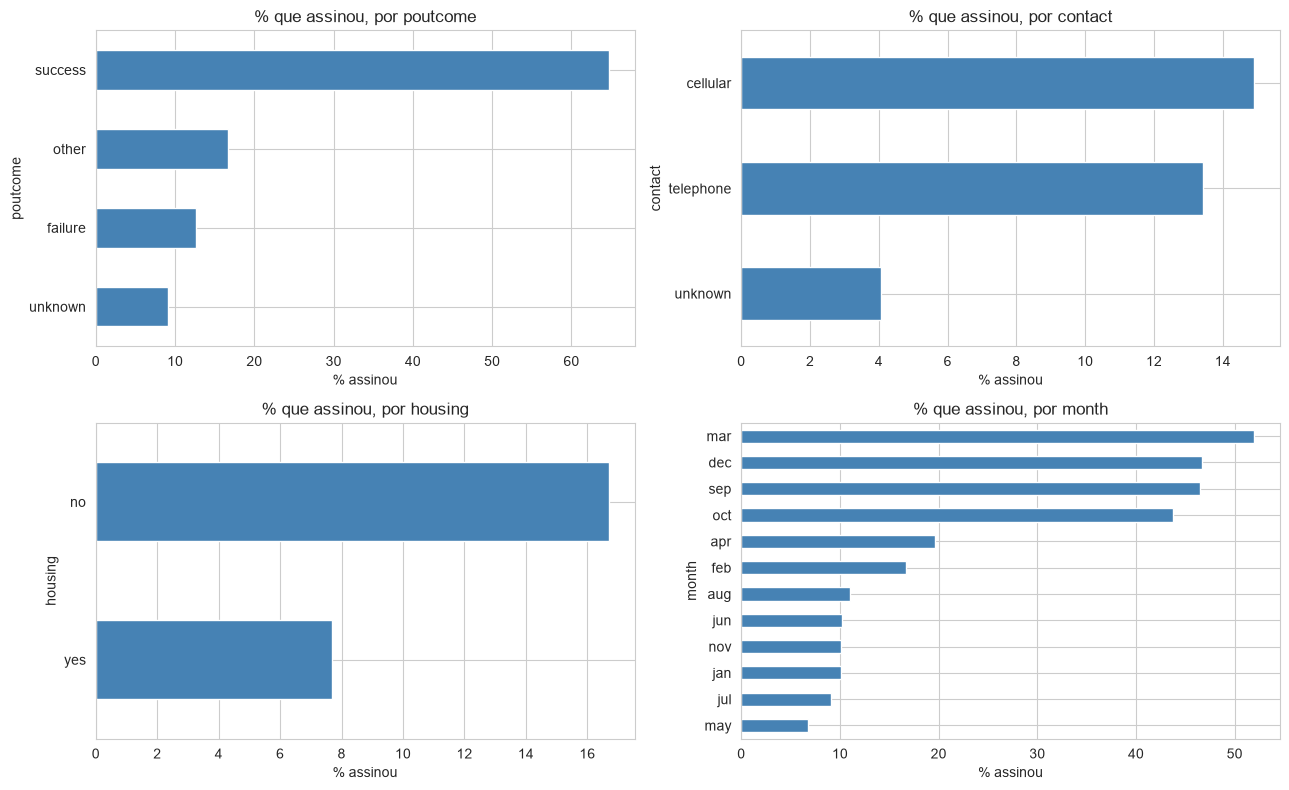

In [11]:
# taxa de conversao por categoria. isso mostra direto a relacao de cada uma com o y.
cats = ['poutcome', 'contact', 'housing', 'month']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.ravel(), cats):
    conv = df.groupby(c)['y'].apply(lambda s: (s == 'yes').mean() * 100).sort_values()
    conv.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'% que assinou, por {c}')
    ax.set_xlabel('% assinou')
plt.tight_layout()
plt.show()

success - o cliente respondeu positivamente à campanha anterior.
failure - a campanha anterior não teve sucesso.
unknown - o cliente não participou de campanhas anteriores ou o resultado não é conhecido.

## 3. Pre-processamento

Tres decisoes aqui, e tentei justificar cada uma porque o teste pede isso.

In [12]:
dados = df.copy()

# alvo: yes/no vira 1/0. fica mais natural pro modelo e pras metricas.
dados['y'] = (dados['y'] == 'yes').astype(int)

# as colunas que sao so sim/nao tambem viram 1/0
for c in ['default', 'housing', 'loan']:
    dados[c] = (dados[c] == 'yes').astype(int)

# categoricas sem ordem natural (tipo de emprego, mes, etc) eu trato com one-hot.
# de proposito nao usei LabelEncoder: ele inventaria uma ordem (admin=0, blue-collar=1, ...)
# que nao existe de verdade, e isso pode confundir o modelo. o one-hot nao cria ordem falsa.
nominais = ['job', 'marital', 'education', 'contact', 'poutcome', 'month']
dados = pd.get_dummies(dados, columns=nominais, drop_first=False, dtype=int)

y = dados['y']
X = dados.drop('y', axis=1)
print(f'features depois do one-hot: {X.shape[1]} colunas')

features depois do one-hot: 48 colunas


### E a normalizacao?

O teste pede pra comentar sobre normalizar e padronizar. Aqui eu optei por nao fazer, e isso e proposital: os tres modelos que vou usar (Random Forest, XGBoost e LightGBM) sao todos baseados em arvore, e arvore nao liga pra escala das variaveis. Ela decide os cortes pela ordem dos valores, nao pela magnitude, entao padronizar `balance` ou `age` nao mudaria o resultado, so colocaria um passo a mais sem ganho.

Se eu fosse usar um modelo linear (uma regressao logistica de baseline, por exemplo), ai sim a padronizacao seria necessaria. Pro que escolhi, nao e.

## 4. Separacao treino e teste

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify no y pra manter a mesma proporcao de assinantes dos dois lados.
# com a base desbalanceada, sem isso o teste podia ficar com pouquissimo positivo.
print(f'treino: {len(X_train):,} | teste: {len(X_test):,}')
print(f'% positivos no treino: {y_train.mean()*100:.1f} | no teste: {y_test.mean()*100:.1f}')

treino: 36,168 | teste: 9,043
% positivos no treino: 11.7 | no teste: 11.7


## 5. Metricas e desbalanceamento

Como so 11% assinaram, a acuracia engana: um modelo que chuta "ninguem assina" ja acerta 88% e nao serve pra nada. Por isso vou olhar principalmente:

- ROC-AUC, que mede a capacidade de separar quem assina de quem nao assina, sem depender do corte
- Recall da classe positiva, porque o que doi pro banco e deixar passar um cliente que assinaria
- Precisao e F1 pra ter o equilibrio entre os dois

Alem das metricas, vou compensar o desbalanceamento dentro dos proprios modelos, com `class_weight` no Random Forest e no LightGBM, e `scale_pos_weight` no XGBoost. Isso faz o modelo dar mais atencao a classe rara em vez de simplesmente ignora-la.

## 6. Treino dos modelos (versao benchmark)

Treino tres modelos de arvore aqui, usando todas as variaveis, inclusive a `duration`. Chamo de "benchmark" porque, como mostro na secao de producao, a `duration` infla os numeros. Serve de referencia, nao e o modelo que eu colocaria no ar.

Registro tudo no MLflow pra conseguir comparar os experimentos depois.

In [14]:
if TEM_MLFLOW:
    try:
        # caminho do Databricks
        mlflow.set_experiment('/Users/jeffersomkorte@gmail.com/bank_marketing_case')
    except Exception:
        # local: cria a pasta mlruns no projeto
        mlflow.set_experiment('bank_marketing_case')
    print('mlflow configurado')
else:
    print('rodando sem mlflow (so nao vai registrar os runs)')

2026/06/17 16:23:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/17 16:23:56 INFO mlflow.store.db.utils: Updating database tables
2026/06/17 16:23:57 INFO mlflow.tracking.fluent: Experiment with name '/Users/jeffersomkorte@gmail.com/bank_marketing_case' does not exist. Creating a new experiment.


mlflow configurado


In [15]:
# pra nao repetir o mesmo bloco tres vezes, faco uma funcaozinha que treina,
# calcula as metricas e ja registra no mlflow se ele estiver disponivel.
def treinar_e_avaliar(modelo, nome, Xtr, ytr, Xte, yte, log_fn=None):
    modelo.fit(Xtr, ytr)
    proba = modelo.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metricas = {
        'accuracy':  accuracy_score(yte, pred),
        'precision': precision_score(yte, pred),
        'recall':    recall_score(yte, pred),
        'f1':        f1_score(yte, pred),
        'roc_auc':   roc_auc_score(yte, proba),
    }

    if TEM_MLFLOW:
        try:
            with mlflow.start_run(run_name=nome):
                mlflow.log_params(modelo.get_params())
                mlflow.log_metrics(metricas)
                if log_fn:
                    log_fn(modelo, 'model')
        except Exception as e:
            print(f'  (aviso: nao consegui registrar no mlflow: {e})')

    print(f'{nome}: AUC {metricas["roc_auc"]:.4f} | '
          f'recall {metricas["recall"]:.4f} | f1 {metricas["f1"]:.4f}')
    return modelo, metricas

In [16]:
# proporcao de negativos por positivo. o xgboost usa isso pra equilibrar as classes.
peso_positivo = (y_train == 0).sum() / (y_train == 1).sum()
resultados = {}

rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5,
                            class_weight='balanced', random_state=42, n_jobs=-1)
_, resultados['Random Forest'] = treinar_e_avaliar(
    rf, 'RandomForest_benchmark', X_train, y_train, X_test, y_test,
    log_fn=mlflow.sklearn.log_model if TEM_MLFLOW else None)

xgb_m = xgb.XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=300,
                          subsample=0.8, colsample_bytree=0.8,
                          scale_pos_weight=peso_positivo, eval_metric='logloss',
                          random_state=42, verbosity=0)
_, resultados['XGBoost'] = treinar_e_avaliar(
    xgb_m, 'XGBoost_benchmark', X_train, y_train, X_test, y_test,
    log_fn=mlflow.xgboost.log_model if TEM_MLFLOW else None)

lgb_m = lgb.LGBMClassifier(num_leaves=31, learning_rate=0.05, n_estimators=400,
                           subsample=0.8, colsample_bytree=0.8,
                           class_weight='balanced', random_state=42, verbose=-1)
_, resultados['LightGBM'] = treinar_e_avaliar(
    lgb_m, 'LightGBM_benchmark', X_train, y_train, X_test, y_test,
    log_fn=mlflow.lightgbm.log_model if TEM_MLFLOW else None)

2026/06/17 16:28:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RandomForest_benchmark: AUC 0.9277 | recall 0.8374 | f1 0.5854


2026/06/17 16:29:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost_benchmark: AUC 0.9289 | recall 0.8138 | f1 0.6100


2026/06/17 16:29:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LightGBM_benchmark: AUC 0.9323 | recall 0.8611 | f1 0.5986


In [17]:
comparacao = pd.DataFrame(resultados).T[['roc_auc', 'recall', 'precision', 'f1', 'accuracy']]
comparacao = comparacao.sort_values('roc_auc', ascending=False)
display(comparacao.round(4))

melhor_nome = comparacao.index[0]
print(f'melhor no benchmark: {melhor_nome} (AUC {comparacao.iloc[0]["roc_auc"]:.4f})')

,roc_auc,recall,precision,f1,accuracy
LightGBM,0.9323,0.8611,0.4587,0.5986,0.8649
XGBoost,0.9289,0.8138,0.4878,0.6100,0.8782
Random Forest,0.9277,0.8374,0.4500,0.5854,0.8612


melhor no benchmark: LightGBM (AUC 0.9323)


## 7. A pegadinha da `duration` e o modelo de producao

Esse e o ponto mais importante do trabalho ate o moemnto.

A `duration` e a duracao da ligacao em segundos. O problema: voce so sabe a duracao depois que a ligacao acaba. E faz sentido que ligacao longa converta mais, porque quem esta interessado fica na linha conversando. Ou seja, a `duration` e quase uma consequencia do resultado, nao uma causa que da pra usar antes.

Na hora de decidir pra quem ligar, a `duration` ainda nao existe. Entao um modelo que depende dela parece otimo no papel e e inutil na operacao. A propria documentacao da base avisa isso.

A forma honesta de tratar e treinar de novo sem a `duration` e medir o tamanho do estrago. Esse modelo sem `duration` e o que eu levaria pra producao.

In [18]:
# tira a duration das features
cols_producao = [c for c in X.columns if c != 'duration']
X_train_prod = X_train[cols_producao]
X_test_prod = X_test[cols_producao]

# uso o mesmo algoritmo nos dois lados pra comparacao ser justa (so muda ter ou nao a duration)
modelo_prod = lgb.LGBMClassifier(num_leaves=31, learning_rate=0.05, n_estimators=400,
                                 subsample=0.8, colsample_bytree=0.8,
                                 class_weight='balanced', random_state=42, verbose=-1)
modelo_prod.fit(X_train_prod, y_train)
proba_prod = modelo_prod.predict_proba(X_test_prod)[:, 1]
auc_prod = roc_auc_score(y_test, proba_prod)

auc_bench = resultados['LightGBM']['roc_auc']
print(f'AUC com duration (benchmark): {auc_bench:.4f}')
print(f'AUC sem duration (producao):  {auc_prod:.4f}')
print(f'diferenca: {auc_bench - auc_prod:.4f}')
print('\nessa queda toda era informacao vazando da duration.')
print('o numero de producao e mais baixo, mas e o numero honesto.')

AUC com duration (benchmark): 0.9323
AUC sem duration (producao):  0.7989
diferenca: 0.1334

essa queda toda era informacao vazando da duration.
o numero de producao e mais baixo, mas e o numero honesto.


## 8. Avaliacao do modelo de producao

Olhando alem do AUC: matriz de confusao, curva ROC e o relatorio por classe. Tudo no modelo sem `duration`, que e o que de fato vale.

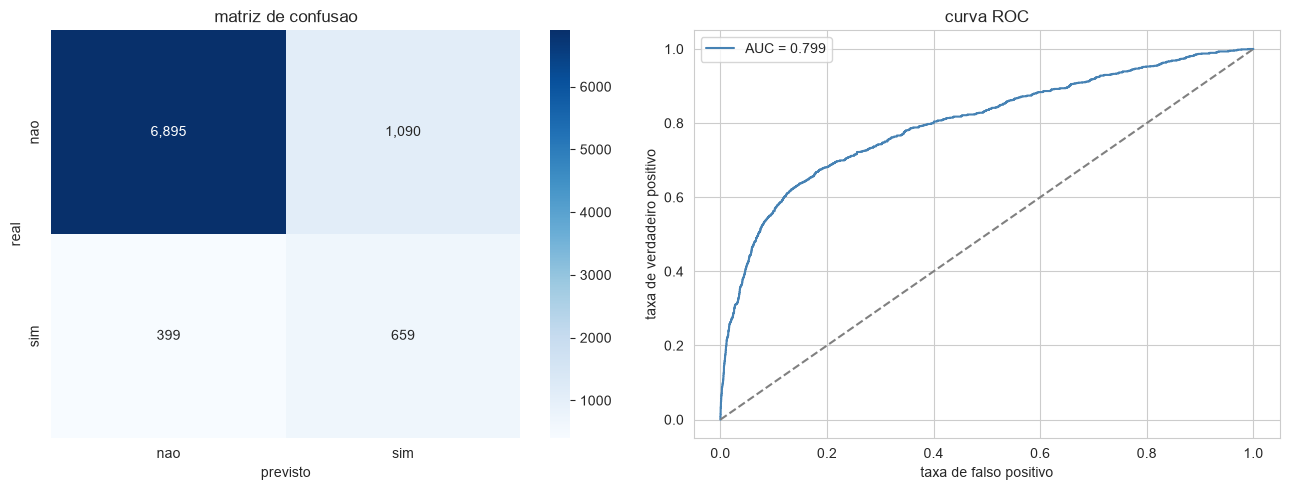

              precision    recall  f1-score   support

 nao assinou       0.95      0.86      0.90      7985
     assinou       0.38      0.62      0.47      1058

    accuracy                           0.84      9043
   macro avg       0.66      0.74      0.69      9043
weighted avg       0.88      0.84      0.85      9043



In [19]:
pred_prod = (proba_prod >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, pred_prod)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['nao', 'sim'], yticklabels=['nao', 'sim'])
axes[0].set_title('matriz de confusao')
axes[0].set_xlabel('previsto')
axes[0].set_ylabel('real')

fpr, tpr, _ = roc_curve(y_test, proba_prod)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {auc_prod:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('curva ROC')
axes[1].set_xlabel('taxa de falso positivo')
axes[1].set_ylabel('taxa de verdadeiro positivo')
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_prod, target_names=['nao assinou', 'assinou']))

### corte de 0.5

O modelo entrega uma probabilidade, e o corte padrao de 0.5 nao e sagrado. Se o banco quer pegar mais assinantes (recall maior) e topa ligar pra mais gente a toa, e so baixar o corte. Se quer economizar ligacao, sobe o corte. 

## 9. Otimizacao de hiperparametros

Ate aqui os parametros foram escolhidos na mao, em valores razoaveis. Pra fazer direito, uso um RandomizedSearchCV em cima do modelo de producao. Prefiro o random ao grid porque cobre mais combinacoes gastando menos tempo, e uso validacao cruzada estratificada pra nao me iludir com um split de sorte. A metrica que mando otimizar e o ROC-AUC, coerente com tudo que falei sobre desbalanceamento.

In [20]:
espaco = {
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400, 600],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 40],
}

busca = RandomizedSearchCV(
    lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    param_distributions=espaco,
    n_iter=15,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
)
busca.fit(X_train_prod, y_train)

print('melhores parametros:', busca.best_params_)
print(f'AUC medio na validacao cruzada: {busca.best_score_:.4f}')

modelo_final = busca.best_estimator_
proba_final = modelo_final.predict_proba(X_test_prod)[:, 1]
auc_final = roc_auc_score(y_test, proba_final)
print(f'AUC no teste com o modelo afinado: {auc_final:.4f}')

if TEM_MLFLOW:
    try:
        with mlflow.start_run(run_name='LightGBM_producao_otimizado'):
            mlflow.log_params(busca.best_params_)
            mlflow.log_metric('roc_auc', auc_final)
            mlflow.lightgbm.log_model(modelo_final, 'model')
    except Exception as e:
        print(f'(aviso mlflow: {e})')

2026/06/17 16:34:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


melhores parametros: {'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 600, 'min_child_samples': 20, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
AUC medio na validacao cruzada: 0.7950
AUC no teste com o modelo afinado: 0.8051


## 10. Variaveis que mais pesam

Aqui costuma vir a duvida: cade o `y` nesse grafico? O `y` e o que a gente esta prevendo, o alvo. Esse grafico mostra so as variaveis de entrada, as que o modelo usa pra chegar na previsao. O `y` nao entra aqui por definicao, e ainda bem: se ele aparecesse, seria sinal de que o modelo esta usando a resposta pra prever a resposta, que e exatamente o tal vazamento.

Uso a importancia do modelo final de producao (sem `duration`), pra ficar coerente com o que de fato iria pro ar.

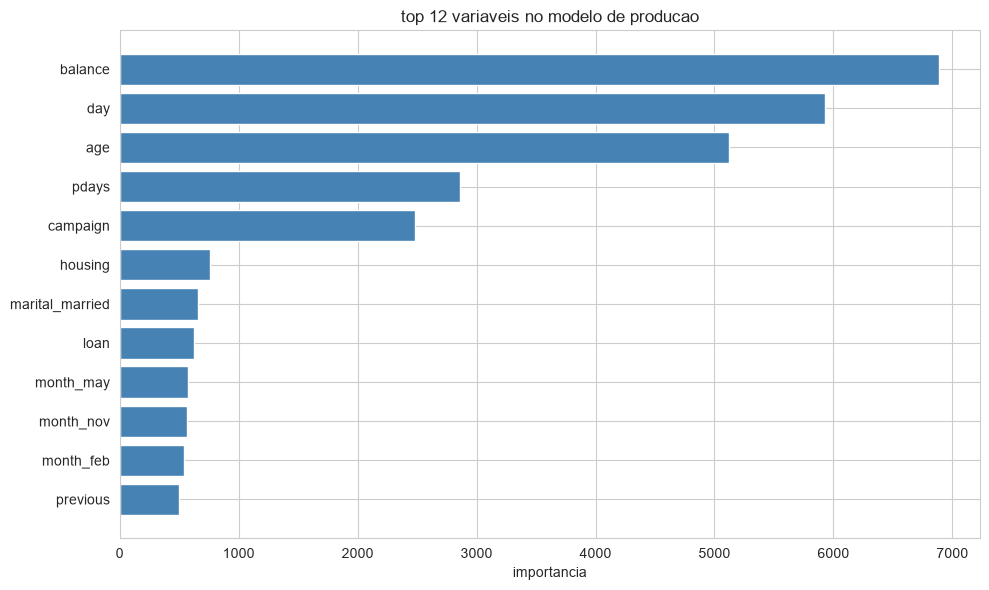

,variavel,peso
0,balance,6888
1,day,5927
2,age,5126
3,pdays,2863
4,campaign,2484
5,housing,762
6,marital_married,656
7,loan,622
8,month_may,574
9,month_nov,566


In [21]:
importancias = pd.DataFrame({
    'variavel': X_train_prod.columns,
    'peso': modelo_final.feature_importances_
}).sort_values('peso', ascending=False).reset_index(drop=True)

top = importancias.head(12)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['variavel'][::-1], top['peso'][::-1], color='steelblue')
ax.set_title('top 12 variaveis no modelo de producao')
ax.set_xlabel('importancia')
plt.tight_layout()
plt.show()

display(top)

## 11. Resumo e recomendacoes pro negocio

In [22]:
top3 = importancias.head(3)['variavel'].tolist()

print('VARIAVEL ALVO (y): o cliente assinou o deposito a prazo, sim ou nao.')
print(f'so {y.mean()*100:.1f}% da base assinou, entao o trabalho e achar essa minoria.\n')

print('MODELO RECOMENDADO: LightGBM sem a variavel duration.')
print(f'  AUC no teste: {auc_final:.4f}')
print(f'  (o mesmo modelo com duration dava {auc_bench:.4f}, mas nao serve pra producao)\n')

print('AS TRES VARIAVEIS QUE MAIS PESAM no modelo realista:')
for i, v in enumerate(top3, 1):
    print(f'  {i}. {v}')

print('\nLEITURA PRO NEGOCIO (vinda da exploracao e do modelo):')
print('  - quem teve campanha anterior bem sucedida (poutcome) e o alvo mais quente')
print('  - canal de contato e mes da ligacao mudam bastante a conversao')
print('  - compensa priorizar quem o modelo da probabilidade alta em vez de ligar pra todo mundo')

VARIAVEL ALVO (y): o cliente assinou o deposito a prazo, sim ou nao.
so 11.7% da base assinou, entao o trabalho e achar essa minoria.

MODELO RECOMENDADO: LightGBM sem a variavel duration.
  AUC no teste: 0.8051
  (o mesmo modelo com duration dava 0.9323, mas nao serve pra producao)

AS TRES VARIAVEIS QUE MAIS PESAM no modelo realista:
  1. balance
  2. day
  3. age

LEITURA PRO NEGOCIO (vinda da exploracao e do modelo):
  - quem teve campanha anterior bem sucedida (poutcome) e o alvo mais quente
  - canal de contato e mes da ligacao mudam bastante a conversao
  - compensa priorizar quem o modelo da probabilidade alta em vez de ligar pra todo mundo


## 12. Como isso roda em producao

Pensando no uso real, e nao so no notebook:

**Pontuacao em lote.** Uma vez por mes o modelo roda em cima da base de clientes e gera, pra cada um, a probabilidade de assinar. A lista sai ordenada da maior pra menor probabilidade, e o time comercial ataca de cima pra baixo, ate onde a capacidade de ligacao do mes permitir. Isso troca a campanha de "liga pra todo mundo" por "liga primeiro pra quem tem mais chance".

**Nada de `duration`.** O modelo de producao nao usa a `duration`, justamente porque ela nao existe antes da ligacao. Esse cuidado e o que separa um numero bonito de um modelo que funciona de verdade.

**Reentreino e monitoramento.** Comportamento de cliente muda, entao eu reentreinaria a cada tres meses com dados novos. E acompanharia o AUC ao longo do tempo: se comecar a cair, ou se a distribuicao das variaveis de entrada mudar muito (data drift), e sinal de reentreinar antes do prazo.

**Ajuste do corte com o negocio.** O limiar de decisao nao e fixo. Ele se calibra comparando quanto custa uma ligacao contra quanto vale um deposito fechado, e isso e conversa com a area comercial, nao decisao isolada do modelo.

**Registro no MLflow.** Cada versao do modelo fica gravada com seus parametros e metricas. Isso facilita comparar versoes, voltar atras se alguma piorar, e saber exatamente qual modelo estava no ar em cada momento.